[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/JMasr/ai-tutorials/blob/main/en/whisper-peft-lora.ipynb)

Author: José Manuel Ramírez Sánchez · https://jmramirez.engineer

# PEFT + LoRA on Whisper: *downstream* classifier vs. embedding extractor

This notebook is a hands-on tutorial -- aimed at readers who already work with
embeddings from self-supervised (SSL) speech models -- on applying **PEFT
(Parameter-Efficient Fine-Tuning)** with **LoRA** adapters to a **Whisper**
model, in two usage modes:

1. **Classifier via a *downstream task***: Whisper plus a classification head
   trained end to end, with the backbone frozen and LoRA injected into the
   encoder's attention.
2. **Feature (embedding) extractor**: the Whisper backbone stays frozen (with no
   permanent task head) and LoRA adapters are added so that the *embeddings* it
   produces can be consumed by an external classifier -- the same pattern as an
   SSL embedding pipeline (HuBERT/WavLM/XLSR/AST) with mean-pooling plus a
   `scikit-learn` classifier inside your cross-validation loop.

In both cases:
- The pretrained backbone is **frozen** (`requires_grad = False`).
- LoRA adapters are inserted only at **strategic points** in the encoder layers
  -- and those points *differ* between the two modes (each section explains why).
- Only a very small fraction of the total parameters is trained.

**Notebook design:**
- Runs entirely on **CPU** (no CUDA or GPU required) -- sidestepping any
  compatibility issues between `torch` and your machine's CUDA drivers.
- Uses **synthetic data** (sine tones generated with `numpy`) instead of real
  audio, so the whole notebook runs in a few minutes and does not depend on any
  external dataset.
- Uses `openai/whisper-tiny` (~39M parameters), the smallest checkpoint in the
  Whisper family, so training is fast on CPU.

> Estimated total runtime: **~4 minutes** on an 8-core CPU without a GPU (including the model download).

**Requirements:** install the dependencies before you start (on Colab, run it in
a cell as `%pip install ...`):

```bash
pip install torch transformers==4.57.6 peft==0.20.0 scikit-learn matplotlib
```

## 0. LoRA on one page

LoRA (*Low-Rank Adaptation*) freezes a pretrained weight matrix
$W_0 \in \mathbb{R}^{d\times k}$ and learns, alongside it, a **low-rank**
update:

$$ W = W_0 + \Delta W = W_0 + B A, \qquad B \in \mathbb{R}^{d\times r},\ A \in \mathbb{R}^{r\times k},\ r \ll \min(d,k) $$

Only $A$ and $B$ are trained; $W_0$ never changes. Because $r$ is small
(typically 4-32), the number of trainable parameters is a tiny fraction of the
full model. The key hyperparameters (we will see them again in the code):

| Hyperparameter | What it controls |
|---|---|
| `r` | rank of the update -- higher = more capacity, more parameters |
| `lora_alpha` | scaling factor for $\Delta W$ (the effective scale is `alpha / r`) |
| `lora_dropout` | dropout applied to the LoRA branch during training |
| `target_modules` | **which layers** get an adapter -- this is what changes between the two modes in this notebook |
| `modules_to_save` | layers that are trained **in full** (no LoRA), typically new, randomly initialized heads |

Why freeze and adapt instead of fine-tuning everything? With a frozen backbone:
(a) the memory/compute cost of training drops dramatically (which is what makes
iterating on CPU feasible here), (b) the resulting checkpoint is an adapter of a
few MB instead of a full copy of the base model, and (c) the risk of
*catastrophic forgetting* of the pretrained knowledge is reduced.

In [1]:
import os

# Force CPU explicitly, regardless of the machine this runs on
# -- avoids any attempt to initialize CUDA (and potential conflicts with the
# GPU driver: we do not even need it here).
os.environ["CUDA_VISIBLE_DEVICES"] = ""

import warnings

warnings.filterwarnings("ignore")

import numpy as np
import torch

torch.manual_seed(0)
np.random.seed(0)
DEVICE = torch.device("cpu")

import peft
import transformers

print("torch       :", torch.__version__)
print("transformers:", transformers.__version__)
print("peft        :", peft.__version__)
print("device      :", DEVICE, "| cuda available:", torch.cuda.is_available())

torch       : 2.14.0+cpu
transformers: 4.57.6
peft        : 0.20.0
device      : cpu | cuda available: False


## 1. Synthetic data

Instead of real audio, we generate synthetic "utterances": 1-second sine tones
at 16 kHz (the sampling rate Whisper expects), with two classes defined by
their base frequency, plus Gaussian noise. There is no pretense of acoustic
realism -- the goal is a signal that is cheap to generate and *learnable*, so we
can verify that the LoRA pipeline actually learns something.

With real data, this cell would be replaced by your data loader (and the 0/1
labels would be, for example, healthy / pathological).

In [2]:
SAMPLE_RATE = 16_000  # required by WhisperFeatureExtractor
DURATION_S = 1.0
CLASS_FREQS = (220.0, 660.0)  # Hz -- one class per base frequency
NOISE_STD = 0.05


def make_example(label: int, rng: np.random.Generator) -> np.ndarray:
    # A 1 s sine tone with frequency jitter + Gaussian noise.
    t = np.linspace(0, DURATION_S, int(SAMPLE_RATE * DURATION_S), endpoint=False)
    base_freq = CLASS_FREQS[label]
    freq = base_freq * (1 + 0.05 * rng.standard_normal())  # +/-5% jitter
    wave = 0.3 * np.sin(2 * np.pi * freq * t)
    wave += NOISE_STD * rng.standard_normal(t.shape)
    return wave.astype(np.float32)


def make_dataset(n_per_class: int, seed: int) -> tuple[list[np.ndarray], list[int]]:
    rng = np.random.default_rng(seed)
    waves, labels = [], []
    for label in (0, 1):
        for _ in range(n_per_class):
            waves.append(make_example(label, rng))
            labels.append(label)
    return waves, labels


train_waves, train_labels = make_dataset(n_per_class=10, seed=2)
val_waves, val_labels = make_dataset(n_per_class=4, seed=3)
print(f"train: {len(train_waves)} examples | val: {len(val_waves)} examples")

train: 20 examples | val: 8 examples


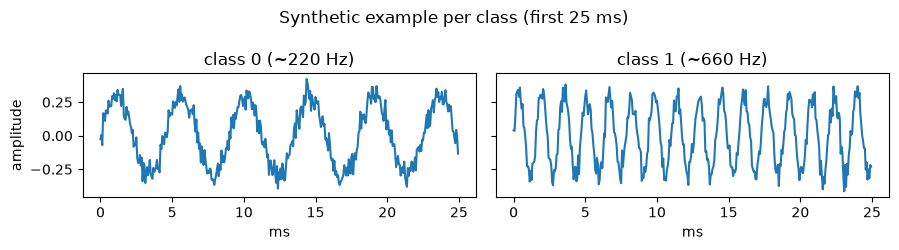

In [3]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(9, 2.5), sharey=True)
for ax, label in zip(axes, (0, 1)):
    idx = train_labels.index(label)
    axes_t = np.arange(400) / SAMPLE_RATE * 1000
    ax.plot(axes_t, train_waves[idx][:400])
    ax.set_title(f"class {label} (~{CLASS_FREQS[label]:.0f} Hz)")
    ax.set_xlabel("ms")
axes[0].set_ylabel("amplitude")
fig.suptitle("Synthetic example per class (first 25 ms)")
fig.tight_layout()
plt.show()

## 2. Whisper feature extractor

`WhisperFeatureExtractor` turns the raw waveform into a log-mel spectrogram
(80 bands). One detail that matters for what follows: **Whisper always operates
on a fixed 30-second window** -- the feature extractor pads any shorter clip up
to 3000 mel frames, and the encoder reduces them to 1500 positions after its
stride-2 convolution. This means the compute cost per clip is constant, even
though our synthetic audio lasts only 1 second.

In [4]:
from transformers import WhisperFeatureExtractor

CHECKPOINT = "openai/whisper-tiny"
feature_extractor = WhisperFeatureExtractor.from_pretrained(CHECKPOINT)

sample_features = feature_extractor(train_waves[:2], sampling_rate=SAMPLE_RATE, return_tensors="pt")
print("input_features shape:", sample_features["input_features"].shape)  # (batch, 80 mel bins, 3000 frames)


def to_batch(waves: list[np.ndarray], labels: list[int]) -> tuple[torch.Tensor, torch.Tensor]:
    feats = feature_extractor(waves, sampling_rate=SAMPLE_RATE, return_tensors="pt")
    return feats["input_features"], torch.tensor(labels)


X_train, y_train = to_batch(train_waves, train_labels)
X_val, y_val = to_batch(val_waves, val_labels)

input_features shape: torch.Size([2, 80, 3000])


## 3. Part A -- Whisper as a classifier via a *downstream task*

We use `WhisperForAudioClassification`: the Whisper encoder + a `projector`
layer + *pooling* + a linear `classifier` head. `projector` and `classifier`
are randomly initialized (they are not part of the pretrained checkpoint), so
**they must be trained in full**; the rest of the encoder can stay frozen apart
from the LoRA adapters.

**Strategic points for this mode:** only `q_proj` and `v_proj` in the
self-attention of each encoder layer. For a classification *decision* it is
enough to let the adapter slightly readjust **what the encoder attends to**;
there is no need to touch the feed-forward projections (`fc1`/`fc2`), which we
will adapt in Part B.

In [5]:
from transformers import WhisperForAudioClassification

classifier_model = WhisperForAudioClassification.from_pretrained(CHECKPOINT, num_labels=2)

n_frozen = sum(p.numel() for p in classifier_model.parameters())
print(f"Total parameters (before PEFT): {n_frozen:,}")

Some weights of WhisperForAudioClassification were not initialized from the model checkpoint at openai/whisper-tiny and are newly initialized: ['classifier.bias', 'classifier.weight', 'projector.bias', 'projector.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Total parameters (before PEFT): 8,307,458


In [6]:
from peft import LoraConfig, get_peft_model

classifier_lora_config = LoraConfig(
    r=8,
    lora_alpha=16,
    lora_dropout=0.05,
    target_modules=["q_proj", "v_proj"],       # encoder attention only
    modules_to_save=["projector", "classifier"],  # new head -> trained in full
)

peft_classifier = get_peft_model(classifier_model, classifier_lora_config)
peft_classifier.print_trainable_parameters()

trainable params: 148,226 || all params: 8,455,684 || trainable%: 1.7530


In [7]:
import time

optimizer = torch.optim.AdamW(
    [p for p in peft_classifier.parameters() if p.requires_grad], lr=1e-3
)


def accuracy(model, X, y) -> float:
    model.eval()
    with torch.no_grad():
        logits = model(input_features=X).logits
    return (logits.argmax(dim=-1) == y).float().mean().item()


print(f"val accuracy before training (frozen backbone, untrained LoRA): {accuracy(peft_classifier, X_val, y_val):.3f}")

BATCH_SIZE = 4
N_EPOCHS = 3
n_train = X_train.shape[0]

t0 = time.time()
peft_classifier.train()
for epoch in range(N_EPOCHS):
    perm = torch.randperm(n_train)
    for i in range(0, n_train, BATCH_SIZE):
        idx = perm[i : i + BATCH_SIZE]
        optimizer.zero_grad()
        out = peft_classifier(input_features=X_train[idx], labels=y_train[idx])
        out.loss.backward()
        optimizer.step()
    peft_classifier.eval()
    print(
        f"epoch {epoch} | loss {out.loss.item():.4f} "
        f"| train acc {accuracy(peft_classifier, X_train, y_train):.3f} "
        f"| val acc {accuracy(peft_classifier, X_val, y_val):.3f} "
        f"| {time.time() - t0:.1f}s"
    )
    peft_classifier.train()

print(f"\nTraining finished in {time.time() - t0:.1f}s (CPU)")

val accuracy before training (frozen backbone, untrained LoRA): 0.500


epoch 0 | loss 0.6387 | train acc 0.500 | val acc 0.500 | 33.0s


epoch 1 | loss 0.2563 | train acc 1.000 | val acc 1.000 | 58.9s


epoch 2 | loss 0.0042 | train acc 1.000 | val acc 1.000 | 86.0s

Training finished in 86.0s (CPU)


### 3.1 Saving and reloading only the adapter

One of PEFT's biggest practical benefits: the checkpoint you need to save
consists only of the LoRA matrices (+ the layers in `modules_to_save`), not the
full model. We verify this by saving it and comparing sizes on disk.

In [8]:
import tempfile
from pathlib import Path

from peft import PeftModel


def dir_size_mb(path: Path) -> float:
    return sum(f.stat().st_size for f in path.rglob("*") if f.is_file()) / 1e6


with tempfile.TemporaryDirectory() as tmp_dir:
    adapter_dir = Path(tmp_dir) / "whisper_tiny_classifier_lora"
    peft_classifier.save_pretrained(adapter_dir)
    adapter_mb = dir_size_mb(adapter_dir)
    print(f"Saved adapter size: {adapter_mb:.2f} MB")
    print(f"Total parameters of the base model: {n_frozen:,} (~{n_frozen * 4 / 1e6:.1f} MB in fp32)")

    # Reload: "clean" base backbone + saved adapter
    base_for_reload = WhisperForAudioClassification.from_pretrained(CHECKPOINT, num_labels=2)
    reloaded = PeftModel.from_pretrained(base_for_reload, adapter_dir)
    print(f"val accuracy after reloading the adapter: {accuracy(reloaded, X_val, y_val):.3f}")

Saved adapter size: 0.60 MB
Total parameters of the base model: 8,307,458 (~33.2 MB in fp32)


Some weights of WhisperForAudioClassification were not initialized from the model checkpoint at openai/whisper-tiny and are newly initialized: ['classifier.bias', 'classifier.weight', 'projector.bias', 'projector.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


val accuracy after reloading the adapter: 1.000


## 4. Part B -- Whisper as a frozen embedding extractor + LoRA

Here there is no permanent classification head: the goal is to produce one
**embedding vector** per clip (just as your SSL embedding pipeline does with
HuBERT/WavLM/XLSR/AST) that can then be consumed by **any** external classifier
-- typically a `scikit-learn` classifier inside your cross-validation loop.

**Strategic points for this mode:** in addition to `q_proj`/`v_proj`, we add
LoRA to `fc1`/`fc2` (the feed-forward projections in each encoder layer). The
difference from Part A is deliberate: there, we only needed to shift a
*decision boundary* downstream of a trainable head; here, there is no head to
absorb the adjustment -- it is the **embedding itself** that has to move, and
the feed-forward layers are the ones that reshape the representation the most
in each transformer block.

Training trick: since we do not want to "bake" a specific task into the
extractor, we temporarily attach a throwaway linear head (*probe*), purely so we
can backpropagate a supervised signal into the LoRA adapters. Once training is
done, we discard the *probe* and keep only the encoder + LoRA as the embedding
extractor.

In [9]:
from transformers import WhisperModel

whisper_full = WhisperModel.from_pretrained(CHECKPOINT)
encoder = whisper_full.get_encoder()

embedding_lora_config = LoraConfig(
    r=4,
    lora_alpha=8,
    lora_dropout=0.05,
    target_modules=["q_proj", "v_proj", "fc1", "fc2"],  # attention + feed-forward
)

peft_encoder = get_peft_model(encoder, embedding_lora_config)
peft_encoder.print_trainable_parameters()

trainable params: 86,016 || all params: 8,294,400 || trainable%: 1.0370


In [10]:
def embed(model, X: torch.Tensor) -> torch.Tensor:
    # Mean-pooling over the time axis of the last hidden state -- the same
    # pooling strategy commonly used with HuBERT/WavLM/XLSR in SSL pipelines.
    model.eval()
    with torch.no_grad():
        hidden_states = model(input_features=X).last_hidden_state
    return hidden_states.mean(dim=1)

In [11]:
from sklearn.linear_model import LogisticRegression

# Embeddings BEFORE training the adapters (LoRA is initialized with
# delta W = 0, so this is equivalent to the "pure" frozen backbone).
emb_train_before = embed(peft_encoder, X_train).numpy()
emb_val_before = embed(peft_encoder, X_val).numpy()

probe_baseline = LogisticRegression(max_iter=1000).fit(emb_train_before, y_train.numpy())
val_acc_before = probe_baseline.score(emb_val_before, y_val.numpy())
print(f"val accuracy (UNADAPTED embeddings + external LogisticRegression): {val_acc_before:.3f}")

val accuracy (UNADAPTED embeddings + external LogisticRegression): 1.000


In [12]:
# Throwaway linear head -- used only to train the LoRA adapters.
scratch_probe = torch.nn.Linear(whisper_full.config.d_model, 2)

optimizer = torch.optim.AdamW(
    list(p for p in peft_encoder.parameters() if p.requires_grad) + list(scratch_probe.parameters()),
    lr=1e-3,
)

N_EPOCHS = 3
n_train = X_train.shape[0]

t0 = time.time()
peft_encoder.train()
for epoch in range(N_EPOCHS):
    perm = torch.randperm(n_train)
    for i in range(0, n_train, BATCH_SIZE):
        idx = perm[i : i + BATCH_SIZE]
        optimizer.zero_grad()
        pooled = peft_encoder(input_features=X_train[idx]).last_hidden_state.mean(dim=1)
        logits = scratch_probe(pooled)
        loss = torch.nn.functional.cross_entropy(logits, y_train[idx])
        loss.backward()
        optimizer.step()
    print(f"epoch {epoch} | loss {loss.item():.4f} | {time.time() - t0:.1f}s")

print(f"\nAdapter training finished in {time.time() - t0:.1f}s (CPU)")

epoch 0 | loss 0.6287 | 31.1s


epoch 1 | loss 0.3482 | 62.4s


epoch 2 | loss 0.0231 | 98.0s

Adapter training finished in 98.0s (CPU)


In [13]:
# Discard scratch_probe -- the only thing we keep is peft_encoder.
emb_train_after = embed(peft_encoder, X_train).numpy()
emb_val_after = embed(peft_encoder, X_val).numpy()

probe_adapted = LogisticRegression(max_iter=1000).fit(emb_train_after, y_train.numpy())
val_acc_after = probe_adapted.score(emb_val_after, y_val.numpy())

print(f"val accuracy (UNADAPTED embeddings): {val_acc_before:.3f}")
print(f"val accuracy (LoRA-ADAPTED embeddings): {val_acc_after:.3f}")

val accuracy (UNADAPTED embeddings): 1.000
val accuracy (LoRA-ADAPTED embeddings): 1.000


> **An honest note on the number above:** the synthetic signal in this notebook
> (a different base frequency per class) is usually already close to linearly
> separable in the *unadapted* embeddings -- an averaged log-mel spectrogram
> already carries that information without any adapter. This is not a
> generalizable result; on real speech tasks (e.g. telling healthy from
> pathological voices), off-the-shelf SSL embeddings are usually not already
> aligned with the task, and that is where adapting with LoRA makes a
> measurable difference. What matters in this section is the **mechanism**: how
> a temporary *probe* is attached, trained and discarded to produce an adapted
> embedding extractor -- that mechanism carries over unchanged to real data.

In [14]:
with tempfile.TemporaryDirectory() as tmp_dir:
    encoder_adapter_dir = Path(tmp_dir) / "whisper_tiny_embedding_lora"
    peft_encoder.save_pretrained(encoder_adapter_dir)
    print(f"Saved embedding adapter size: {dir_size_mb(encoder_adapter_dir):.2f} MB")

Saved embedding adapter size: 0.35 MB


## 5. Summary

| | Part A: *downstream* classifier | Part B: embedding extractor |
|---|---|---|
| `transformers` class | `WhisperForAudioClassification` | `WhisperModel.get_encoder()` |
| LoRA `target_modules` | `q_proj`, `v_proj` | `q_proj`, `v_proj`, `fc1`, `fc2` |
| `modules_to_save` | `projector`, `classifier` | *(none -- no permanent head)* |
| What you keep at the end | the full PEFT model (encoder+LoRA+head) | only `peft_encoder` (encoder+LoRA); the training head is discarded |
| Downstream usage | `model(...).logits` directly | embeddings -> external `scikit-learn` classifier (inside your cross-validation) |

**Key takeaways:**
- Freezing the backbone and using LoRA is not "a single recipe": **which
  layers** you adapt (`target_modules`) depends on whether the adjustment has to
  shift a decision boundary (attention is enough) or reshape the representation
  itself (worth adding the feed-forward layers).
- `modules_to_save` is for **new** (not pretrained) layers that need to be
  trained in full -- giving them only a low-rank adapter makes no sense when
  they start from random weights.
- A LoRA adapter checkpoint is a couple of orders of magnitude smaller than the
  base model -- handy for versioning/sharing many experiments.
- This whole workflow runs on CPU with `openai/whisper-tiny`; to move to real
  data, the only piece that changes is Section 1 (replace `make_dataset` with
  your data loader) and, to speed up training on large datasets, move
  `DEVICE`/the checkpoint to a larger Whisper on a GPU.

**References:**
- LoRA: Hu et al., 2021 -- [arXiv:2106.09685](https://arxiv.org/abs/2106.09685)
- PEFT (Hugging Face docs): https://huggingface.co/docs/peft
- Whisper: Radford et al., 2022 -- [arXiv:2212.04356](https://arxiv.org/abs/2212.04356)
- `WhisperForAudioClassification`: https://huggingface.co/docs/transformers/model_doc/whisper#transformers.WhisperForAudioClassification